# Deep learning pour le texte
L'objectif de ce TP est d'apprivoiser les embeddings de mots, de tokens, ainsi que les architectures Transformers. Voici ce que nous allons aborder :
- Chargement des embeddings pré-entrainés
- Manipulation des embeddings
- Visualuation des embeddings
- Classification de phrases courtes, en fonction de différentes représentations et architectures
- Classification de textes : Finetuning d'un Transformer pre-entraîné sur le corpus IMDB

Vous aurez besoin des installations suivantes (en plus de pytorch et numpy):
- conda install pandas
- conda install matplotlib
- conda install -c anaconda scikit-learn
- conda install ipywidgets
- conda install gensim
- conda install datasets
- conda install -c huggingface transformers
- conda install tqdm




 ## Configuration environnement

In [1]:
import torch

# pour colab, decommenter:
# !pip install torch==1.8.0+cu111 torchtext==0.9.0 torchvision==0.9.0+cu111 torchaudio==0.8.0 -f https://download.pytorch.org/whl/torch_stable.html

print(torch.__version__)

2.10.0+cpu


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

# Progrès
from tqdm import tqdm
from tqdm.autonotebook import tqdm

import pandas as pd
import numpy as np

import transformers
print(transformers.__version__)

/tmp/ipykernel_160/449048064.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


5.0.0


In [3]:
!pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.0 MB/s eta 0:00:00


## Chargement d'embeddings et calculs de similarité

Pour commencer à travailler sur le texte, nous allons dans un premier temps utiliser un ensemble de vecteurs d'embeddings appris via le modèle Glove (similaire à Word2Vec vu en cours), que nous allons charger via la librairie gensim (il s'agit d'un ensemble d'embeddings parmi d'autres, de nombreux autres, appris sur des corpus différents existent dans gensim ou d'autres librairies comme spacy).

In [4]:
import gensim.downloader as api
embeds = api.load("glove-wiki-gigaword-50")

# affichage de l'embedding du mot "book"
print(embeds['book'])

[==================================================] 100.0% 66.0/66.0MB downloaded
[-0.0076543  0.93456   -0.73189   -0.55162    0.76977    0.35925
 -1.1365    -1.1632     0.34214    0.29145   -0.8711     0.9197
 -0.47069   -0.22834    1.4777    -0.81714   -0.17466   -0.51093
 -0.28354    0.23292    0.71832    0.23414    0.49443    0.35483
  0.76889   -1.4374    -1.7457    -0.28994   -0.10156   -0.36959
  2.5502    -1.0581    -0.049416  -0.25524   -0.63303    0.02671
 -0.18733    0.20206   -0.26288   -0.41418    0.83473   -0.14227
 -0.28125    0.098155  -0.17096    0.52408    0.31851   -0.089847
 -0.27223   -0.0088736]


In [5]:
# Methode most_similar permet d'obtenir les mots les plus proches d'un mot dans l'espace d'embeddings. sa specification peut être obtenue en executant la ligne suivante :
help(embeds.most_similar)

Help on method most_similar in module gensim.models.keyedvectors:

most_similar(positive=None, negative=None, topn=10, clip_start=0, clip_end=None, restrict_vocab=None, indexer=None) method of gensim.models.keyedvectors.KeyedVectors instance
    Find the top-N most similar keys.
    Positive keys contribute positively towards the similarity, negative keys negatively.

    This method computes cosine similarity between a simple mean of the projection
    weight vectors of the given keys and the vectors for each key in the model.
    The method corresponds to the `word-analogy` and `distance` scripts in the original
    word2vec implementation.

    Parameters
    ----------
    positive : list of (str or int or ndarray) or list of ((str,float) or (int,float) or (ndarray,float)), optional
        List of keys that contribute positively. If tuple, second element specifies the weight (default `1.0`)
    negative : list of (str or int or ndarray) or list of ((str,float) or (int,float) or (n

# Afficher les 5 mots les plus proches de "cat" via la méthode model.most_similar

In [6]:
similar_words = embeds.most_similar("cat", topn=10)

for word, score in similar_words:
    print(f"{word} : {score:.4f}")

dog : 0.9218
rabbit : 0.8488
monkey : 0.8041
rat : 0.7892
cats : 0.7865
snake : 0.7799
dogs : 0.7796
pet : 0.7792
mouse : 0.7732
bite : 0.7729


In [7]:
"cat" in embeds.key_to_index

True

In [8]:
# La similarité est calculée selon une mesure de cosinus dans l'espace des embeddings
# par exemple
print(embeds.similarity("apple", "banana"))
print(embeds.similarity("apple", "dog"))

0.5607928
0.4138724


### Out Of Distribution
Attention, bien sûr tous les mots possibles ne sont pas inclus dans le dictionnaire d'embeddings, leur sémantique dépend notamment fortement du corpus sur lequel ils ont été appris.

Par exemple le mot "covid" n'est pas présent, l'execution de model['covid'] ferait planter l'execution.

Pour éviter ce genre de problème par exemple pour le traitement d'un texte ne contenant pas certains mots, ils convient de vérifier leur présence dans le vocabulaire (et alors ignorer les mots correspondants). Ceci peut se faire via vocab.keys comme ci-dessous.

In [9]:
# Le vocabulaire du modèle peut être obtenus via vocab.keys, qui retourne l'ensemble des tokens (mots) pour lesquels il existe un embedding dans le modèle
vocab = embeds.key_to_index.keys()
np.random.choice(list(vocab), 5)

x="covid"
if x in vocab:
    print(embeds[x])
else: print("oov")


oov


### Visualisation des embeddings

On souhaite maintenant visualiser les embeddings dans un espace en 2D. Pour cela, on utilise t-SNE.

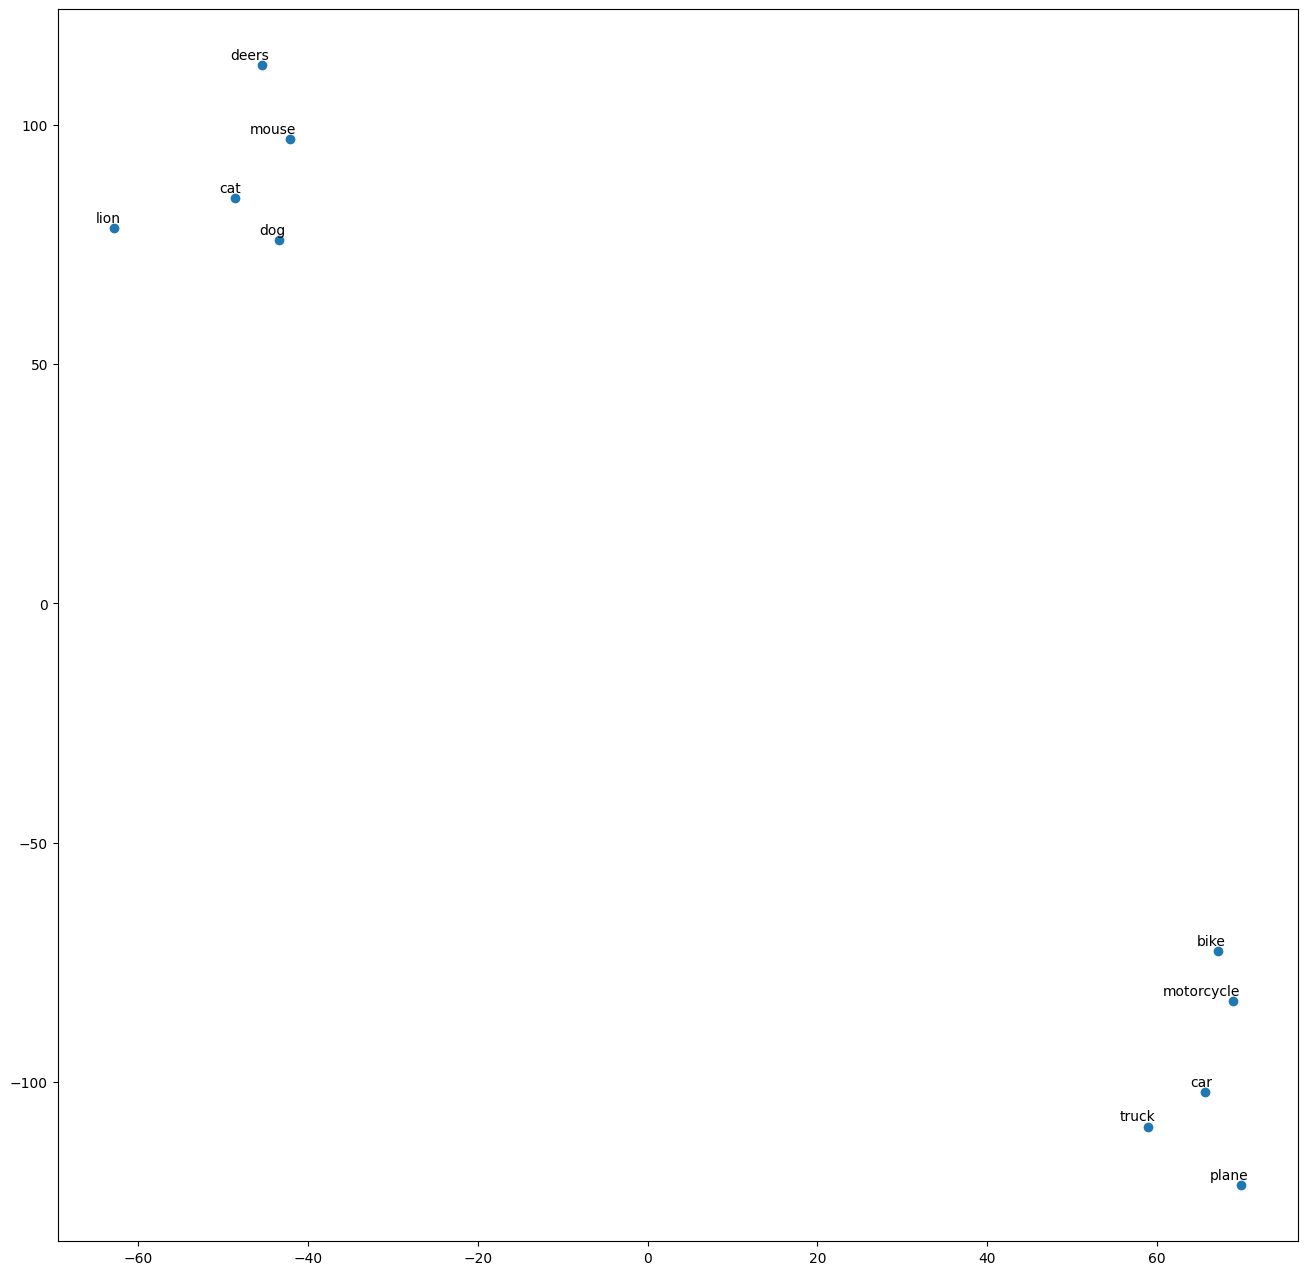

In [10]:
words=['cat','mouse','dog','car','truck','motorcycle','bike','lion','plane','deers']

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def tsne_plot(model, words,n_components=2,perplexity=40):
    "Creates and TSNE model and plots it"
    labels = []
    tokens = []
    vocab = model.key_to_index.keys()

    for word in words:
        if word in vocab:
            tokens.append(model[word])
            labels.append(word)

    tsne_model = TSNE(perplexity=perplexity, n_components=n_components, init='pca', max_iter=2500, random_state=23)
    new_values = tsne_model.fit_transform(np.array(tokens))
    fig = plt.figure(figsize=(16, 16))
    if n_components==3:
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(new_values[:,0],new_values[:,1],new_values[:,2],c="r",marker="o")
        for i in range(len(new_values)):
            ax.text(new_values[i][0],new_values[i][1],new_values[i][2],labels[i])
    else:
        plt.scatter(new_values[:,0],new_values[:,1])
        for i in range(len(new_values)):
            plt.annotate(labels[i],
                        xy=(new_values[i][0],new_values[i][1]),
                        xytext=(5, 2),
                        textcoords='offset points',
                        ha='right',
                        va='bottom')
    return new_values,labels

new_values,labels = tsne_plot(embeds,words,n_components=2,perplexity=2)

### Index des Embeddings

Lors de l'établissement de modèles utilisant les embeddings du vocabulaire, il est utile de considérer des indices des mots dans le vocabulaire plutôt que les mots eux mêmes (pour les traiter par exemple dans des tenseurs avant de les remplacer par leurs vecteurs de poids). Ceci se fait dans gensim par l'utilisation des instructions suivantes:  

In [11]:
print(embeds.key_to_index["book"])
print(embeds.index_to_key[539])

# Deux manières equivalentes de recupérer les poids
print(embeds["book"])   # via le mot
print(embeds.vectors[embeds.key_to_index["book"]]) #via l'index


# taille du vocabulaire:
print(embeds.vectors.shape)


539
book
[-0.0076543  0.93456   -0.73189   -0.55162    0.76977    0.35925
 -1.1365    -1.1632     0.34214    0.29145   -0.8711     0.9197
 -0.47069   -0.22834    1.4777    -0.81714   -0.17466   -0.51093
 -0.28354    0.23292    0.71832    0.23414    0.49443    0.35483
  0.76889   -1.4374    -1.7457    -0.28994   -0.10156   -0.36959
  2.5502    -1.0581    -0.049416  -0.25524   -0.63303    0.02671
 -0.18733    0.20206   -0.26288   -0.41418    0.83473   -0.14227
 -0.28125    0.098155  -0.17096    0.52408    0.31851   -0.089847
 -0.27223   -0.0088736]
[-0.0076543  0.93456   -0.73189   -0.55162    0.76977    0.35925
 -1.1365    -1.1632     0.34214    0.29145   -0.8711     0.9197
 -0.47069   -0.22834    1.4777    -0.81714   -0.17466   -0.51093
 -0.28354    0.23292    0.71832    0.23414    0.49443    0.35483
  0.76889   -1.4374    -1.7457    -0.28994   -0.10156   -0.36959
  2.5502    -1.0581    -0.049416  -0.25524   -0.63303    0.02671
 -0.18733    0.20206   -0.26288   -0.41418    0.83473   -0

on a 400.000 mots de 50 dimensions

#### Exercice 1 : Similarité de phrases

On souhaite calculer la matrice de similarité de différentes phrases du dataset suivant:




In [12]:
tdf = pd.DataFrame([
    ['the road is straight', 'Y'],
    ['the black cat plays with a ball', 'N'],
    ['a big dog with a ball', 'N'],
    ['dog and cat are together', 'N'],
    ['traffic jam on the 6th road', 'Y'],
    ['white bird on a big tree', 'N'],
    ['a big truck', 'Y'],
    ['two cars crashed', 'Y'],
    ['two deers in a field', 'N'],
    ['I like ridding my bike','Y'],
    ['a lion in the savane','N'],
    ['a motorcycle rides on the road','Y'],
    ['it is a bike, it is not a flamingo', 'Y'],
    ['it is not a bike, it is a flamingo', 'N'],
    ['a mouse bitten by a cat','N'],
    ['two pigs in the mood','N'],
    ['take a plane is sometimes slower than taking train','Y'],
    ['take the highway','Y']
], columns=['text', 'label'])
tdf

,text,label
0,the road is straight,Y
1,the black cat plays with a ball,N
2,a big dog with a ball,N
3,dog and cat are together,N
4,traffic jam on the 6th road,Y
5,white bird on a big tree,N
6,a big truck,Y
7,two cars crashed,Y
8,two deers in a field,N
9,I like ridding my bike,Y


In [13]:
tdf['text']

,text
0,the road is straight
1,the black cat plays with a ball
2,a big dog with a ball
3,dog and cat are together
4,traffic jam on the 6th road
5,white bird on a big tree
6,a big truck
7,two cars crashed
8,two deers in a field
9,I like ridding my bike


Pour chaque phrase, on va moyenner les embeddings de ces mots. Chaque vecteur de phrase sera normalisé (x.norm()). Les phrases pourront être comparées deux à deux par un produit scalaire.

- chaque phrase doit être découpée : ("the", "cat", "is" , "on", "the","bank")
- on définit une fonction getvectors qui à partir de la liste de phrases découpées : moyenne les vecteurs d'embeddings (pensez à utiliser les tenseurs de torch), normalise le resultat et le retourne.
- on peut ensuite calculer la matrice de similarité qui sera donnée à la fonction visual_similarity_matrix() fournie ci-dessous.

In [14]:
import gensim
def getlistwordsentence2(text):
    ret=[]
    for sentence in text:
        ret.append(list(gensim.utils.tokenize(sentence)))
    return ret

worldlist = getlistwordsentence2(tdf['text'])
print(worldlist)

[['the', 'road', 'is', 'straight'], ['the', 'black', 'cat', 'plays', 'with', 'a', 'ball'], ['a', 'big', 'dog', 'with', 'a', 'ball'], ['dog', 'and', 'cat', 'are', 'together'], ['traffic', 'jam', 'on', 'the', 'th', 'road'], ['white', 'bird', 'on', 'a', 'big', 'tree'], ['a', 'big', 'truck'], ['two', 'cars', 'crashed'], ['two', 'deers', 'in', 'a', 'field'], ['I', 'like', 'ridding', 'my', 'bike'], ['a', 'lion', 'in', 'the', 'savane'], ['a', 'motorcycle', 'rides', 'on', 'the', 'road'], ['it', 'is', 'a', 'bike', 'it', 'is', 'not', 'a', 'flamingo'], ['it', 'is', 'not', 'a', 'bike', 'it', 'is', 'a', 'flamingo'], ['a', 'mouse', 'bitten', 'by', 'a', 'cat'], ['two', 'pigs', 'in', 'the', 'mood'], ['take', 'a', 'plane', 'is', 'sometimes', 'slower', 'than', 'taking', 'train'], ['take', 'the', 'highway']]


In [15]:
stop_list =["in","a","the","it","is","to","with"]
stop_list += list(gensim.parsing.preprocessing.STOPWORDS)
# Premiere possibilité :
def getlistwordsentence(text):
    ret=[]
    for sentence in text:
        print(sentence)
        ret.append(sentence.split(" "))
    return ret


# Deuxième possibilité (plus robuste, gère la ponctuation, etc.):
import gensim
def getlistwordsentence2(text):
    ret=[]
    for sentence in text:
        ret.append(list(gensim.utils.tokenize(sentence)))
    return ret

worldlist = getlistwordsentence2(tdf['text'])
print(worldlist)

def getvectors(wordlist, normalize=True):
    l=[]
    s=[]
    mots_connus =  embeds.key_to_index.keys()

    for mots in wordlist:
        x=torch.cat([torch.Tensor(embeds[x]).view(1,-1) for x in mots if x in mots_connus and x not in stop_list],0)
        x=x.mean(0)
        if normalize:
            x/=x.norm(dim=-1)
            l.append(x)
            s.append("".join(words))

    return torch.stack(l), s

x, sentences = getvectors(worldlist,True)

print(x)

[['the', 'road', 'is', 'straight'], ['the', 'black', 'cat', 'plays', 'with', 'a', 'ball'], ['a', 'big', 'dog', 'with', 'a', 'ball'], ['dog', 'and', 'cat', 'are', 'together'], ['traffic', 'jam', 'on', 'the', 'th', 'road'], ['white', 'bird', 'on', 'a', 'big', 'tree'], ['a', 'big', 'truck'], ['two', 'cars', 'crashed'], ['two', 'deers', 'in', 'a', 'field'], ['I', 'like', 'ridding', 'my', 'bike'], ['a', 'lion', 'in', 'the', 'savane'], ['a', 'motorcycle', 'rides', 'on', 'the', 'road'], ['it', 'is', 'a', 'bike', 'it', 'is', 'not', 'a', 'flamingo'], ['it', 'is', 'not', 'a', 'bike', 'it', 'is', 'a', 'flamingo'], ['a', 'mouse', 'bitten', 'by', 'a', 'cat'], ['two', 'pigs', 'in', 'the', 'mood'], ['take', 'a', 'plane', 'is', 'sometimes', 'slower', 'than', 'taking', 'train'], ['take', 'the', 'highway']]


/tmp/ipykernel_160/3976991597.py:29: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  x=torch.cat([torch.Tensor(embeds[x]).view(1,-1) for x in mots if x in mots_connus and x not in stop_list],0)


tensor([[-1.1732e-01,  1.3151e-01,  4.9436e-02,  1.8232e-02, -4.9698e-02,
         -4.5390e-03, -1.5438e-01,  3.6965e-02,  2.2421e-02, -1.2168e-01,
         -1.9089e-01, -1.3619e-01, -2.7093e-01, -7.3582e-02, -8.3371e-02,
         -3.7438e-02,  6.4854e-02, -7.6205e-02, -1.9868e-01, -6.0244e-02,
         -3.5489e-02, -3.7762e-02, -2.9201e-02,  7.0597e-02,  7.9802e-02,
         -2.5481e-01,  6.6310e-02,  1.1648e-01,  1.4857e-01, -1.7376e-01,
          6.3345e-01,  6.2604e-02,  9.2780e-02,  9.3652e-02,  1.3171e-01,
         -2.4060e-02,  7.7119e-02,  1.0160e-01, -7.1482e-02, -1.7718e-02,
         -1.2226e-01, -1.0449e-01, -9.0691e-04, -1.6065e-02, -6.3408e-02,
          4.6364e-02,  1.0833e-01, -2.2836e-01,  9.8499e-02, -9.8926e-02],
        [-1.4148e-01,  7.8508e-03, -1.4451e-01, -4.0373e-02,  1.0120e-01,
          1.1684e-01, -1.6415e-01, -7.7096e-02, -3.5983e-02,  1.5913e-02,
          3.8953e-02,  1.1954e-01, -3.1264e-02,  9.6204e-02,  3.3887e-02,
         -6.1185e-02,  9.8346e-02,  3

In [16]:
def getSims(x):
    n=x.shape[0]
    innerproducts=torch.zeros(n,n)
    for i in range(n):
        for j in range(n):
            innerproducts[i,j]=torch.dot(x[i],x[j])
    return innerproducts
innerproducts=getSims(x)
print(innerproducts)

tensor([[ 1.0000,  0.6535,  0.6989,  0.3406,  0.7952,  0.6297,  0.6999,  0.6040,
          0.4339,  0.6452,  0.0070,  0.7247,  0.4739,  0.4739,  0.2512,  0.2778,
          0.6682,  0.6770],
        [ 0.6535,  1.0000,  0.9203,  0.7601,  0.4964,  0.7820,  0.6651,  0.4064,
          0.4923,  0.6235,  0.2183,  0.5228,  0.3906,  0.3906,  0.6904,  0.4890,
          0.5456,  0.2673],
        [ 0.6989,  0.9203,  1.0000,  0.7931,  0.5747,  0.8031,  0.7889,  0.4745,
          0.5352,  0.7028,  0.2115,  0.5854,  0.4475,  0.4475,  0.7017,  0.5273,
          0.6147,  0.2956],
        [ 0.3406,  0.7601,  0.7931,  1.0000,  0.3325,  0.7296,  0.5666,  0.3382,
          0.3234,  0.5415,  0.4626,  0.5140,  0.5033,  0.5033,  0.9047,  0.5775,
          0.4314,  0.1226],
        [ 0.7952,  0.4964,  0.5747,  0.3325,  1.0000,  0.5412,  0.7170,  0.5941,
          0.3402,  0.6281,  0.0980,  0.7409,  0.5005,  0.5005,  0.2216,  0.2896,
          0.7024,  0.6868],
        [ 0.6297,  0.7820,  0.8031,  0.7296,  0.54

In [17]:
import numpy as np
import matplotlib.pyplot as plt


def visual_similarity_matrix(innerproducts):
    """
    Affiche une matrice de similarité / produits scalaires sans labels.

    Args:
        innerproducts (torch.Tensor or np.ndarray): matrice (n, n)
    """

    # Conversion si tensor PyTorch
    if hasattr(innerproducts, "detach"):
        innerproducts = innerproducts.detach().cpu().numpy()

    n = innerproducts.shape[0]

    fig, ax = plt.subplots(figsize=(8, 8))

    im = ax.imshow(innerproducts, cmap="viridis")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Ticks simples (indices)
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))

    ax.set_xticklabels(np.arange(n))
    ax.set_yticklabels(np.arange(n))

    # Annotations numériques
    for i in range(n):
        for j in range(n):
            ax.text(
                j,
                i,
                f"{innerproducts[i, j]:.2f}",
                ha="center",
                va="center",
                color="white" if innerproducts[i, j] < innerproducts.max() / 2 else "black",
                fontsize=9,
            )

    ax.set_title("Matrice de similarité (produit scalaire)")
    fig.tight_layout()
    plt.show()


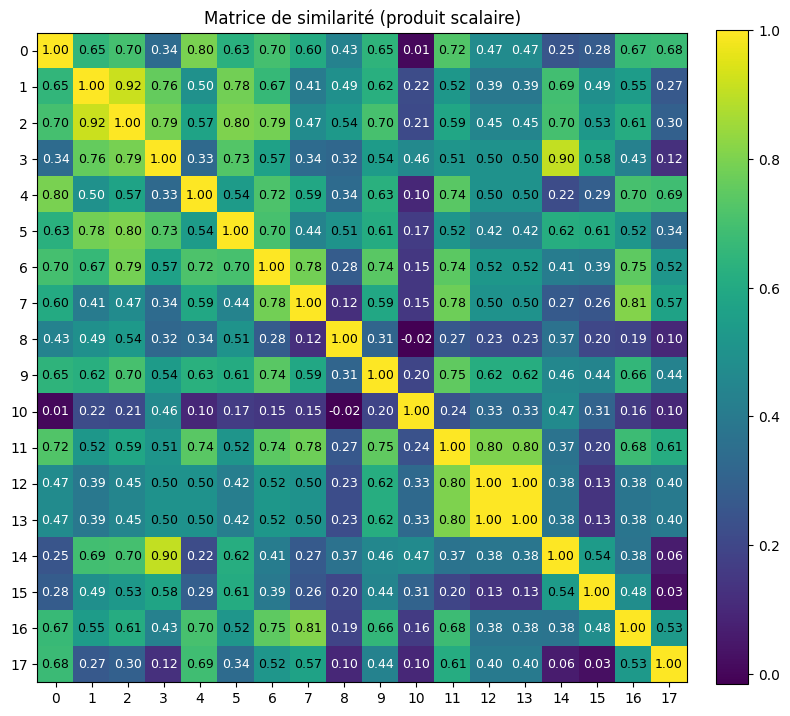

In [18]:
innerproducts = getSims(x)
visual_similarity_matrix(innerproducts)

## Utilisation des embeddings pour une tâche de classification

On s'intéresse maintenant à apprendre un classifieur sur les données de l'exemple jouet défini ci dessus. On utilisera le jeu de données suivant comme jeu de validation :



In [19]:
vdf = pd.DataFrame([
    ['the bike drives on the road', 'Y'],
    ['a lion and a cat in a tree', 'N'],
    ['two cars crashed', 'Y'],
    ['i always go to work by bike', 'Y'],
    ['i have no animal at home', 'N'],
    ['dogs like cheese', 'N'],
    ['a pink flamingo','N'],
    ['trucks','Y'],
    ['truckks','Y'],
    ['truckmegatruck', 'Y'],
    ['a text about trucks, not animals','Y'],
    ['a text about animals, not trucks','N'],
    ['doggs','N']
], columns=['text', 'label'])
vdf

,text,label
0,the bike drives on the road,Y
1,a lion and a cat in a tree,N
2,two cars crashed,Y
3,i always go to work by bike,Y
4,i have no animal at home,N
5,dogs like cheese,N
6,a pink flamingo,N
7,trucks,Y
8,truckks,Y
9,truckmegatruck,Y


La première étape  consiste à transformer les données (label numérique, tokenization, construction d'un batch.)

In [20]:
import datasets
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_pandas(tdf)
validation_dataset = Dataset.from_pandas(vdf)
print(train_dataset,validation_dataset)
print(train_dataset["text"])

# Creation d'un index de padding pour les positions a ignorer par le modèle (e.g., mots inconnus)
pad_idx=embeds.vectors.shape[0]



def preprocess_function(examples):
    vocab=embeds.key_to_index
    inputs= getlistwordsentence2(examples["text"])

    inputs = [[(vocab[word] if word in vocab else pad_idx) for word in sentence] for sentence in inputs]

    labels = [(1 if l=='Y' else 0) for l in examples["label"]]
    ret = {}
    ret["input_ids"]=inputs
    ret["labels"]=labels

    return ret


train_dataset = train_dataset.map(preprocess_function, batched=True, remove_columns=train_dataset.features.keys(), load_from_cache_file=True)
print(train_dataset)
print(train_dataset["input_ids"])
validation_dataset = validation_dataset.map(preprocess_function, batched=True, remove_columns=validation_dataset.features.keys(), load_from_cache_file=True)
print(validation_dataset)
print(validation_dataset["input_ids"])

Dataset({
    features: ['text', 'label'],
    num_rows: 18
}) Dataset({
    features: ['text', 'label'],
    num_rows: 13
})
Column(['the road is straight', 'the black cat plays with a ball', 'a big dog with a ball', 'dog and cat are together', 'traffic jam on the 6th road'])


Map:   0%|          | 0/18 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'labels'],
    num_rows: 18
})
Column([[0, 586, 14, 1362], [0, 521, 5450, 1381, 17, 7, 1083], [7, 365, 2926, 17, 7, 1083], [2926, 5, 5450, 32, 600], [1596, 8202, 13, 0, 14358, 586]])


Map:   0%|          | 0/13 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'labels'],
    num_rows: 13
})
Column([[0, 7696, 5919, 13, 0, 586], [7, 6657, 5, 7, 5450, 6, 7, 2654], [55, 1277, 3732], [41, 690, 242, 4, 161, 21, 7696], [41, 33, 84, 2694, 22, 163]])


In [21]:
#!pip install --upgrade --force-reinstall transformers

In [22]:
import torch
import numpy as np
from torch.utils.data import DataLoader, Sampler

batchsize = 4
megabatch_mul = 16
pad_idx = 0  # ou tokenizer.pad_token_id


def get_length_grouped_indices(lengths, batch_size, megabatch_mul=None):
    import random
    indices = list(range(len(lengths)))
    random.shuffle(indices)

    if megabatch_mul is None:
        megabatch_mul = 50

    megabatch_size = batch_size * megabatch_mul

    grouped = []
    for i in range(0, len(indices), megabatch_size):
        megabatch = indices[i:i + megabatch_size]
        megabatch.sort(key=lambda i: lengths[i], reverse=True)
        grouped.extend(megabatch)

    return grouped


class LengthGroupedSampler(Sampler):
    def __init__(self, batch_size, dataset, megabatch_mul=None):
        self.batch_size = batch_size
        self.megabatch_mul = megabatch_mul
        self.lengths = [len(sample["input_ids"]) for sample in dataset]

    def __len__(self):
        return len(self.lengths)

    def __iter__(self):
        indices = get_length_grouped_indices(
            self.lengths, self.batch_size, self.megabatch_mul
        )
        return iter(indices)


def data_collator(batch):
    first = batch[0]
    ret = {}

    dtype = torch.long if isinstance(first["labels"], int) else torch.float
    ret["labels"] = torch.tensor([f["labels"] for f in batch], dtype=dtype)

    longest = max(len(x["input_ids"]) for x in batch)
    s = np.stack([
        np.pad(x["input_ids"], (0, longest - len(x["input_ids"])),
               constant_values=pad_idx)
        for x in batch
    ])

    ret["input_ids"] = torch.tensor(s, dtype=torch.long)
    return ret


train_sampler = LengthGroupedSampler(batchsize, train_dataset, megabatch_mul)

train_loader = DataLoader(
    train_dataset,
    batchsize,
    sampler=train_sampler,
    collate_fn=data_collator,
    pin_memory=True,
    shuffle=False,
    num_workers=0,
)

for data in train_loader:
    print(data)


test_sampler = LengthGroupedSampler(batchsize, validation_dataset, megabatch_mul)

test_loader = DataLoader(
    validation_dataset,
    batchsize,
    sampler=test_sampler,
    collate_fn=data_collator,
    pin_memory=True,
    shuffle=False,
    num_workers=0,
)

{'labels': tensor([0, 1, 1, 0]), 'input_ids': tensor([[   20,    14,    36,     7,  7696,    20,    14,     7, 35115],
        [   20,    14,     7,  7696,    20,    14,    36,     7, 35115],
        [  190,     7,  1313,    14,  1071,  6914,    73,   582,  1470],
        [    0,   521,  5450,  1381,    17,     7,  1083,     0,     0]])}
{'labels': tensor([0, 1, 0, 0]), 'input_ids': tensor([[  298,  2632,    13,     7,   365,  2654],
        [    7,  7213,  9371,    13,     0,   586],
        [    7,  7571, 22022,    21,     7,  5450],
        [    7,   365,  2926,    17,     7,  1083]])}
{'labels': tensor([1, 0, 0, 0]), 'input_ids': tensor([[  1596,   8202,     13,      0,  14358,    586],
        [    55,   9609,      6,      0,   5030,      0],
        [     7,   6657,      6,      0, 232439,      0],
        [    55, 134183,      6,      7,    610,      0]])}
{'labels': tensor([1, 0, 1, 1]), 'input_ids': tensor([[400000,    117,  40085,    192,   7696],
        [  2926,      5,   5

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [23]:
### On peut créer une fonction de décodage des batchs
def batch_decode(input_ids):
    x = input_ids.detach().cpu().numpy()
    vocab_size = len(embeds.index_to_key)

    decoded = []
    for s in x:
        words = []
        for i in s:
            i = int(i)
            if i == pad_idx:
                continue
            if 0 <= i < vocab_size:
                words.append(embeds.index_to_key[i])
            else:
                words.append("<UNK>")
        decoded.append(" ".join(words))

    return decoded

In [24]:
for data in test_loader:
    print(data)
    print(batch_decode(data["input_ids"]))

{'labels': tensor([0, 1, 1, 0]), 'input_ids': tensor([[   7, 6657,    5,    7, 5450,    6,    7, 2654],
        [  41,  690,  242,    4,  161,   21, 7696,    0],
        [   7, 2829,   59, 3597,   36, 2430,    0,    0],
        [   7, 2829,   59, 2430,   36, 3597,    0,    0]])}
['a lion and a cat in a tree', 'i always go to work by bike', 'a text about trucks not animals', 'a text about animals not trucks']
{'labels': tensor([1, 0, 0, 1]), 'input_ids': tensor([[   0, 7696, 5919,   13,    0,  586],
        [  41,   33,   84, 2694,   22,  163],
        [3876,  117, 5795,    0,    0,    0],
        [  55, 1277, 3732,    0,    0,    0]])}
['bike drives on road', 'i have no animal at home', 'dogs like cheese', 'two cars crashed']
{'labels': tensor([0, 1, 0, 1]), 'input_ids': tensor([[     7,   5491,  35115],
        [  3597,      0,      0],
        [400000,      0,      0],
        [400000,      0,      0]])}
['a pink flamingo', 'trucks', '<UNK>', '<UNK>']
{'labels': tensor([1]), 'input_i

On note que le dernier texte "truckmegatruck" est décodé sous la chaîne vide: il ne contient que des mots inconnus, donc ignorés...

### Modèle de classifcation simple

On construit ensuite le modèle de classification avec torch. La couche d'entrée correspond aux embeddings, implémentés par nn.Embedding(). nn.Embedding() permet de construire la matrice d'embeddings sur l'ensemble du vocabulaire. Ils sont ensuite "activés" en fonction du texte d'entrée. Le modèle à construire fait une simple moyenne des embeddings des mots des textes, applique une activation tanh et envoie le resultat à travers un Linear à deux sorties. Penser à indiquer l'index de padding à la construction de nn.Embedding, car çà permet de ne pas les prendre en compte dans les calculs de gradients (et de conserver ces embeddings vides à zeros pour ne pas en dépendre => invariance par rapport à la longueur). Penser aussi à ajouter de la l2 sur les embeddings (très importants pour que les représentations ne s'éparpillent pas aux confins de l'espace de représentation!). On pourra aussi ajouter du Dropout.

In [25]:
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

# modele de classification
# EXEMPLE : net = MyModel(pad_idx+1,50,pad_idx,0.0)

class MyModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, pad_idx, dropout_rate):
        super(MyModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(embed_dim, 2)

    def forward(self, input_ids):
        embeds = self.embedding(input_ids)
        mask = (input_ids != pad_idx).unsqueeze(-1).float()
        summed = torch.sum(embeds * mask, dim=1)
        counts = torch.clamp(mask.sum(dim=1), min=1e-9)
        averaged = summed / counts
        x = torch.tanh(averaged)
        x = self.dropout(x)
        logits = self.fc1(x)
        return logits

On entraîne et teste le modèle.

In [28]:
def train_test(train_iter, test_iter, model, loss_function, optimizer, epochs, clip=-1):
  for epoch in range(epochs):
      epoch_loss = 0
      epoch_accuracy = 0
      model.train()
      nb_samples=0
      model_device = next(model.parameters()).device # Get model's device once
      for batch in train_iter:
          optimizer.zero_grad()
          #print("text shape ",batch.text.T.shape)
          prediction = model(batch["input_ids"].to(model_device))
          if not isinstance(prediction,torch.Tensor):
                prediction = prediction["logits"]
          #print(prediction)
          loss = loss_function(prediction, batch["labels"].to(model_device))

          loss.backward()
          if clip>0:
              torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
          optimizer.step()
          nb_samples+=prediction.shape[0]
          epoch_loss+=loss.item()*prediction.shape[0]
          preds=(prediction[:,1]>prediction[:,0])*1.0
          accuracy=(preds==batch["labels"].to(model_device)).sum()
          epoch_accuracy+=accuracy.item()
      print('train loss on epoch {} : {:.3f}'.format(epoch, epoch_loss/nb_samples))
      print('train accuracy on epoch {}: {:.3f}'.format(epoch, epoch_accuracy/nb_samples))

      model.eval()
      test_loss = 0
      test_accuracy = 0
      nb_samples=0
      accuracy=0
      # model_device = next(model.parameters()).device # Get model's device once for test loop as well
      for batch in test_iter:
          #print("test ",batch)
          with torch.no_grad():
              optimizer.zero_grad()

              prediction = model(batch["input_ids"].to(model_device))
              if not isinstance(prediction,torch.Tensor):
                    prediction = prediction["logits"]
              loss = loss_function(prediction, batch["labels"].to(model_device))
              nb_samples+=prediction.shape[0]
              test_loss+=loss.item()*prediction.shape[0]
              #print(batch_decode(batch["input_ids"]))
              preds=(prediction[:,1]>prediction[:,0])*1.0
              accuracy=(preds==batch["labels"].to(model_device)).sum()
              test_accuracy+=accuracy.item()
              #print(preds,accuracy)

In [29]:
# penser à ajouter un embedding pour pad_idx
from torch.utils.data import DataLoader
#from transformers.trainer_pt_utils import LengthGroupedSampler,Sampler,get_length_grouped_indices
#from torch.optim.lr_scheduler import _LRScheduler as LRScheduler
train_loader=DataLoader(train_dataset,batchsize,sampler=train_sampler,collate_fn=data_collator,pin_memory=True, shuffle=False, num_workers=0)
batchsize=4
megabatch_mul=16
#[[Answer

pad_idx=embeds.vectors.shape[0]
net = MyModel(pad_idx+1,50,pad_idx,0.0)
#/Answer]]

loss_function = nn.CrossEntropyLoss()
optimizer = Adam(net.parameters(), lr=0.01,weight_decay=0.01)
epochs = 200
train_test(train_loader, test_loader, net, loss_function, optimizer, epochs)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


train loss on epoch 0 : 0.632
train accuracy on epoch 0: 0.667
train loss on epoch 1 : 0.518
train accuracy on epoch 1: 0.778
train loss on epoch 2 : 0.445
train accuracy on epoch 2: 0.778
train loss on epoch 3 : 0.394
train accuracy on epoch 3: 0.889
train loss on epoch 4 : 0.349
train accuracy on epoch 4: 0.889
train loss on epoch 5 : 0.317
train accuracy on epoch 5: 0.944
train loss on epoch 6 : 0.292
train accuracy on epoch 6: 0.944
train loss on epoch 7 : 0.272
train accuracy on epoch 7: 0.944
train loss on epoch 8 : 0.255
train accuracy on epoch 8: 0.944
train loss on epoch 9 : 0.240
train accuracy on epoch 9: 0.944
train loss on epoch 10 : 0.227
train accuracy on epoch 10: 0.944
train loss on epoch 11 : 0.215
train accuracy on epoch 11: 0.944
train loss on epoch 12 : 0.206
train accuracy on epoch 12: 0.944
train loss on epoch 13 : 0.199
train accuracy on epoch 13: 0.944
train loss on epoch 14 : 0.193
train accuracy on epoch 14: 0.944
train loss on epoch 15 : 0.188
train accuracy

In [30]:
def predict(sentence,model):
    examples={}
    examples["text"]=[sentence]
    examples["label"]=["Y"]
    data=preprocess_function(examples)
    #print(data)
    data=data_collator([data])
    #print(data["input_ids"])
    model.eval()
    with torch.no_grad():
        prediction = model(data["input_ids"][0])
        if not isinstance(prediction,torch.Tensor):
            prediction = prediction["logits"]
        preds=(prediction[:,1]>prediction[:,0])*1.0
    return {"logits":prediction,"prediction":preds}

def predict_from_pandas(datap,net):
    data=Dataset.from_pandas(vdf)
    accuracy=0
    size=len(data["text"])
    for i in range(size):
        s=data["text"][i]
        l=data["label"][i]
        l=(1 if l=='Y' else 0)
        p=predict(s,net)
        print(s,p, "truth=",l)
        accuracy+=(p["prediction"]==l)
    return accuracy/size

print(predict_from_pandas(vdf,net))


the bike drives on the road {'logits': tensor([[-1.2042,  1.2051]]), 'prediction': tensor([1.])} truth= 1
a lion and a cat in a tree {'logits': tensor([[ 1.9485, -1.9484]]), 'prediction': tensor([0.])} truth= 0
two cars crashed {'logits': tensor([[-1.5135,  1.5144]]), 'prediction': tensor([1.])} truth= 1
i always go to work by bike {'logits': tensor([[-0.1688,  0.1694]]), 'prediction': tensor([1.])} truth= 1
i have no animal at home {'logits': tensor([[-0.1211,  0.1218]]), 'prediction': tensor([1.])} truth= 0
dogs like cheese {'logits': tensor([[-0.5490,  0.5497]]), 'prediction': tensor([1.])} truth= 0
a pink flamingo {'logits': tensor([[ 0.6132, -0.6127]]), 'prediction': tensor([0.])} truth= 0
trucks {'logits': tensor([[-0.1215,  0.1221]]), 'prediction': tensor([1.])} truth= 1
truckks {'logits': tensor([[-0.1215,  0.1221]]), 'prediction': tensor([1.])} truth= 1
truckmegatruck {'logits': tensor([[-0.1215,  0.1221]]), 'prediction': tensor([1.])} truth= 1
a text about trucks, not animals

On observe beaucoup de sur-apprentissage. Normal étant donné la taille du corpus d'apprentissage...


### Même modèle mais avec des embeddings pré-entraînés

 Voyons ce que celà donne avec les représentations pre-entrainées (que l'on freeze)

#### Méthode 1 : directement fournir les embeddings construits à partir du vocab

In [31]:

#[[Answer
net = MyModel(pad_idx+1,50,pad_idx,0.0)
weights= torch.concat([torch.Tensor(embeds.vectors), torch.zeros(1,embeds.vectors.shape[1])],0) # on ajoute un vecteur de zeros pour le padding
#/Answer]]

net.embedding.weight.data=weights   # on charge les pre-train
net.embedding.weight.requires_grad=False  # on freeze
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(net.parameters(), lr=0.01,weight_decay=0.0)
epochs = 200

train_test(train_loader, test_loader, net, loss_function, optimizer, epochs,clip=1)


train loss on epoch 0 : 0.660
train accuracy on epoch 0: 0.556
train loss on epoch 1 : 0.548
train accuracy on epoch 1: 0.944
train loss on epoch 2 : 0.471
train accuracy on epoch 2: 0.944
train loss on epoch 3 : 0.414
train accuracy on epoch 3: 0.944
train loss on epoch 4 : 0.367
train accuracy on epoch 4: 0.944
train loss on epoch 5 : 0.326
train accuracy on epoch 5: 0.944
train loss on epoch 6 : 0.291
train accuracy on epoch 6: 0.944
train loss on epoch 7 : 0.264
train accuracy on epoch 7: 0.944
train loss on epoch 8 : 0.243
train accuracy on epoch 8: 0.944
train loss on epoch 9 : 0.226
train accuracy on epoch 9: 0.944
train loss on epoch 10 : 0.212
train accuracy on epoch 10: 0.944
train loss on epoch 11 : 0.199
train accuracy on epoch 11: 0.944
train loss on epoch 12 : 0.189
train accuracy on epoch 12: 0.944
train loss on epoch 13 : 0.180
train accuracy on epoch 13: 0.944
train loss on epoch 14 : 0.172
train accuracy on epoch 14: 0.944
train loss on epoch 15 : 0.165
train accuracy

#### Méthode 2 : avec la méthode nn.Embedding.from_pretrained()

nn.Embedding permet d'importer directement une matrice de poids (embeddings pré-entraînés) grâce à la méthode from_pretrained() :  
```
weight = torch.FloatTensor([[1, 2.3, 3], [4, 5.1, 6.3]])
embedding = nn.Embedding.from_pretrained(weight)
```
Plus particulièrement, la matrice de poids correspond à notre élément vocab.vectors qui va permettre d'initialiser la matrice d'embeddings.

Par défaut, les embeddings sont "gelés" : ils ne sont pas modifiés avec la backpropagation, mais il est possible de les modifier avec le paramètre freeze=False. Cela revient à "fine-tuner" les embeddings sur la tâche.

In [32]:
#[[Answer
net = MyModel(pad_idx+1,50,pad_idx,0.0)

# Create the full weight matrix including the padding embedding
# embeds.vectors has shape (vocab_size, embed_dim)
# We need to add one row for the pad_idx at the end
initial_weights = torch.cat([torch.Tensor(embeds.vectors), torch.zeros(1, embeds.vectors.shape[1])], dim=0)

# Re-initialize the embedding layer of the model using from_pretrained
# By default, freeze=True, which is what we want here
net.embedding = nn.Embedding.from_pretrained(initial_weights, freeze=True, padding_idx=pad_idx)
#/Answer]]

loss_function = nn.CrossEntropyLoss()
optimizer = Adam(net.parameters(), lr=0.01,weight_decay=0.0)
epochs = 200
train_test(train_loader, test_loader, net, loss_function, optimizer, epochs)

train loss on epoch 0 : 0.698
train accuracy on epoch 0: 0.611
train loss on epoch 1 : 0.572
train accuracy on epoch 1: 0.833
train loss on epoch 2 : 0.487
train accuracy on epoch 2: 0.944
train loss on epoch 3 : 0.426
train accuracy on epoch 3: 0.944
train loss on epoch 4 : 0.378
train accuracy on epoch 4: 0.944
train loss on epoch 5 : 0.338
train accuracy on epoch 5: 0.944
train loss on epoch 6 : 0.303
train accuracy on epoch 6: 0.944
train loss on epoch 7 : 0.276
train accuracy on epoch 7: 0.944
train loss on epoch 8 : 0.254
train accuracy on epoch 8: 0.944
train loss on epoch 9 : 0.235
train accuracy on epoch 9: 0.944
train loss on epoch 10 : 0.221
train accuracy on epoch 10: 0.944
train loss on epoch 11 : 0.209
train accuracy on epoch 11: 0.944
train loss on epoch 12 : 0.198
train accuracy on epoch 12: 0.944
train loss on epoch 13 : 0.189
train accuracy on epoch 13: 0.944
train loss on epoch 14 : 0.181
train accuracy on epoch 14: 0.944
train loss on epoch 15 : 0.174
train accuracy

In [33]:
print(predict_from_pandas(vdf,net))

the bike drives on the road {'logits': tensor([[-3.9944,  4.0876]]), 'prediction': tensor([1.])} truth= 1
a lion and a cat in a tree {'logits': tensor([[ 3.3106, -3.3723]]), 'prediction': tensor([0.])} truth= 0
two cars crashed {'logits': tensor([[-5.0301,  5.0444]]), 'prediction': tensor([1.])} truth= 1
i always go to work by bike {'logits': tensor([[-1.4643,  1.4272]]), 'prediction': tensor([1.])} truth= 1
i have no animal at home {'logits': tensor([[ 0.8913, -1.1969]]), 'prediction': tensor([0.])} truth= 0
dogs like cheese {'logits': tensor([[ 3.0866, -3.6966]]), 'prediction': tensor([0.])} truth= 0
a pink flamingo {'logits': tensor([[ 3.8335, -3.7882]]), 'prediction': tensor([0.])} truth= 0
trucks {'logits': tensor([[-6.9493,  7.0315]]), 'prediction': tensor([1.])} truth= 1
truckks {'logits': tensor([[ 0.0760, -0.0127]]), 'prediction': tensor([0.])} truth= 1
truckmegatruck {'logits': tensor([[ 0.0760, -0.0127]]), 'prediction': tensor([0.])} truth= 1
a text about trucks, not animals

Ok c'est beaucoup mieux, mais on a toujours des limites importantes:
- Pas de prise en compte de l'ordre des mots : on voit que "a text about trucks, not animals" et "a text about animals, not trucks" retournent exactement les mêmes scores de prediction
- Pas de gestion des mots hors vocabulaire. Exemple truckmegatruck n'est pas géré, et retourne exactement les mêmes predictions que les deux textes avec fautes de frappe truckks et doggs

###  Tokenizers

Pour aller plus loin, on propose maintenant d'utiliser des tokens issus d'un tokenizer plus évolué, du type Byte Pair Encoding vu en cours, pour voir si cela pourrait améliorer les performances.

On commence par récupérer un tokenizer pré-entraîné sur un corpus :

In [34]:

from transformers import AutoTokenizer, DistilBertForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# De la même manière qu'avec Glove, on peut observer le vocabulaire :
print(tokenizer.vocab)

vocab_size=len(tokenizer.vocab)
print("Size of Vocab : ",vocab_size)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'motel': 14901, 'quantity': 11712, 'olsen': 18997, 'archival': 22796, 'kali': 19924, '##ger': 4590, '##body': 23684, 'santiago': 8728, 'rebranded': 18233, '[unused747]': 752, '##hetic': 20086, 'aggregator': 24089, '##ש': 29812, 'does': 2515, 'chopped': 24881, 'pet': 9004, '[unused417]': 422, 'roderick': 28326, 'rigorous': 20001, 'residential': 5647, '110': 7287, 'corpse': 11547, '##द': 29861, '₂': 1549, 'জ': 1358, 'cochrane': 22329, '##信': 30293, 'administrative': 3831, '##flict': 29301, 'richards': 9712, 'commitment': 8426, 'ezra': 16245, 'sl': 22889, '1953': 4052, '[unused840]': 845, '1989': 2960, 'sichuan': 20980, '1995': 2786, 'salute': 17664, 'serge': 21747, 'worcester': 12539, 'striking': 8478, 'cockpit': 13828, '##pling': 14353, 'terra': 14403, 'noun': 15156, 'european': 2647, 'doctoral': 11316, 'bosnia': 9562, 'disorders': 10840, 'mainz': 19876, '##pf': 14376, 'aerodynamic': 28033, 'term': 2744, 'rags': 26346, 'mbc': 27262, 'mcdowell': 25005, 'accommodation': 11366, '##eke': 2

Pour pouvoir utiliser ce tokenizer dans nos modèles, il faut recréer le datasets.

Donner ci-dessous le code de la fonction preprocess_function à utiliser maintenant :

In [35]:
# On recrée nos datasets initiaux que l'on va traiter différemment :
train_dataset = Dataset.from_pandas(tdf)
validation_dataset = Dataset.from_pandas(vdf)


def preprocess_function(examples):
    #[[Answer
    tokenized_inputs = tokenizer(examples["text"], truncation=True)
    labels = [(1 if l == 'Y' else 0) for l in examples["label"]]
    tokenized_inputs["labels"] = labels
    return tokenized_inputs
    #/Answer]]

train_dataset = train_dataset.map(preprocess_function, batched=True, remove_columns=train_dataset.features.keys(), load_from_cache_file=True)
print(train_dataset)
print(train_dataset["input_ids"])
validation_dataset = validation_dataset.map(preprocess_function, batched=True, remove_columns=validation_dataset.features.keys(), load_from_cache_file=True)
print(validation_dataset)
print(validation_dataset["input_ids"])

Map:   0%|          | 0/18 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 18
})
Column([[101, 1996, 2346, 2003, 3442, 102], [101, 1996, 2304, 4937, 3248, 2007, 1037, 3608, 102], [101, 1037, 2502, 3899, 2007, 1037, 3608, 102], [101, 3899, 1998, 4937, 2024, 2362, 102], [101, 4026, 9389, 2006, 1996, 5351, 2346, 102]])


Map:   0%|          | 0/13 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 13
})
Column([[101, 1996, 7997, 9297, 2006, 1996, 2346, 102], [101, 1037, 7006, 1998, 1037, 4937, 1999, 1037, 3392, 102], [101, 2048, 3765, 8007, 102], [101, 1045, 2467, 2175, 2000, 2147, 2011, 7997, 102], [101, 1045, 2031, 2053, 4111, 2012, 2188, 102]])


In [36]:
pad_idx=tokenizer.pad_token_id  # On met à jour l'index de padding et on recrée les dataloaders

train_sampler = LengthGroupedSampler(batchsize, train_dataset, megabatch_mul)

train_loader=DataLoader(train_dataset,batchsize,sampler=train_sampler,collate_fn=data_collator,pin_memory=True, shuffle=False, num_workers=0)

for data in train_loader:
    print(data)
    print(tokenizer.batch_decode(data["input_ids"]))

test_sampler = LengthGroupedSampler(batchsize, validation_dataset, megabatch_mul)

test_loader=DataLoader(validation_dataset,batchsize,sampler=test_sampler,collate_fn=data_collator,pin_memory=True, shuffle=False, num_workers=0)


for data in test_loader:
    print(data)
    print(tokenizer.batch_decode(data["input_ids"]))



{'labels': tensor([1, 0, 1, 0]), 'input_ids': tensor([[  101,  2009,  2003,  1037,  7997,  1010,  2009,  2003,  2025,  1037,
         19091,  2080,   102],
        [  101,  2009,  2003,  2025,  1037,  7997,  1010,  2009,  2003,  1037,
         19091,  2080,   102],
        [  101,  2202,  1037,  4946,  2003,  2823, 12430,  2084,  2635,  3345,
           102,     0,     0],
        [  101,  1996,  2304,  4937,  3248,  2007,  1037,  3608,   102,     0,
             0,     0,     0]])}
['[CLS] it is a bike, it is not a flamingo [SEP]', '[CLS] it is not a bike, it is a flamingo [SEP]', '[CLS] take a plane is sometimes slower than taking train [SEP] [PAD] [PAD]', '[CLS] the black cat plays with a ball [SEP] [PAD] [PAD] [PAD] [PAD]']
{'labels': tensor([0, 1, 0, 1]), 'input_ids': tensor([[  101,  1037,  8000, 19026,  2011,  1037,  4937,   102],
        [  101,  4026,  9389,  2006,  1996,  5351,  2346,   102],
        [  101,  2317,  4743,  2006,  1037,  2502,  3392,   102],
        [  101,  1

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


On note que truckmegatruck n'est plus complètement ignoré mais découpé en tokens (on retrouve par exemple le token truck d'id 4744 au début du mot).

On a donc un nouvel encodage de notre corpus, mais nous ne possédons pas d'embeddings pour les tokens correspondants. On peut essayer d'en récupérer en chargeant un modèle transformer pre-entraîné :

In [37]:
distil_bert = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased")
print(distil_bert)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


On se propose d'extraire les embeddings de ce modèle pour les utiliser directement dans notre modèle simple MyModel défini plus haut. Donner la procédure pour charger ces embeddings et lancer l'entraînement du modèle.

In [38]:

# Initialize MyModel with the tokenizer's vocab_size and the embedding dimension from distil_bert
# The embed_dim for distilbert-base-uncased is 768.
current_embed_dim = distil_bert.distilbert.embeddings.word_embeddings.weight.shape[-1]
net = MyModel(vocab_size, current_embed_dim, pad_idx, 0.0)

# Load the pretrained DistilBert word embeddings into MyModel's embedding layer
# Set freeze=True to prevent these embeddings from being updated during training
net.embedding = nn.Embedding.from_pretrained(distil_bert.distilbert.embeddings.word_embeddings.weight, freeze=True, padding_idx=pad_idx)

# Define loss function and optimizer. Only optimize parameters that require gradients (i.e., the classifier layer).
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(filter(lambda p: p.requires_grad, net.parameters()), lr=0.01, weight_decay=0.0)
epochs = 200 # Using 200 epochs for consistency with previous simple model training

# Train the model
train_test(train_loader, test_loader, net, loss_function, optimizer, epochs)

# Evaluate the model on the validation set
print(predict_from_pandas(vdf, net))



train loss on epoch 0 : 0.689
train accuracy on epoch 0: 0.667
train loss on epoch 1 : 0.623
train accuracy on epoch 1: 0.889
train loss on epoch 2 : 0.586
train accuracy on epoch 2: 0.833
train loss on epoch 3 : 0.554
train accuracy on epoch 3: 0.833
train loss on epoch 4 : 0.519
train accuracy on epoch 4: 0.889
train loss on epoch 5 : 0.486
train accuracy on epoch 5: 0.889
train loss on epoch 6 : 0.456
train accuracy on epoch 6: 0.944
train loss on epoch 7 : 0.429
train accuracy on epoch 7: 0.944
train loss on epoch 8 : 0.407
train accuracy on epoch 8: 0.944
train loss on epoch 9 : 0.386
train accuracy on epoch 9: 0.944
train loss on epoch 10 : 0.369
train accuracy on epoch 10: 0.944
train loss on epoch 11 : 0.350
train accuracy on epoch 11: 0.944
train loss on epoch 12 : 0.334
train accuracy on epoch 12: 0.944
train loss on epoch 13 : 0.319
train accuracy on epoch 13: 0.944
train loss on epoch 14 : 0.307
train accuracy on epoch 14: 0.944
train loss on epoch 15 : 0.295
train accuracy

Ok pas vraiment mieux qu'avec les embeddings de mots (et même plutôt moins bien!). Pourquoi d'après vous ?

\#[[Answer



\#/Answer]]

# Adaptation d'un modèle pre-entraîné : DistillBert

On va plutôt essayer de re-utiliser le modèle DistillBert complet, en ne fine-tunant que la dernière couche linéaire. Donner la procédure pour réaliser cela et lancer l'entraînement.

In [39]:
#On va plutôt essayer de re-utiliser le modèle DistillBert complet, en ne fine-tunant que la dernière couche linéaire. Donner la procédure pour réaliser cela et lancer l'entraînement.

#ANSWER[[
import torch.nn as nn
from transformers import DistilBertForSequenceClassification

distil_bert = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased")

def set_parameter_requires_grad(model, requires_grad):
    for param in model.parameters():
        param.requires_grad = requires_grad

# Freeze all parameters initially
set_parameter_requires_grad(distil_bert, False)

# Unfreeze the classifier layer
# In DistilBertForSequenceClassification, the classifier is typically called 'classifier'
set_parameter_requires_grad(distil_bert.classifier, True)

# Also unfreeze the pre_classifier layer if present and needed for fine-tuning the head
# This layer connects the pooled output to the final classifier
if hasattr(distil_bert, 'pre_classifier'):
    set_parameter_requires_grad(distil_bert.pre_classifier, True)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = distil_bert.to(device)

# Only optimize parameters that require gradients
params_to_update = [param for param in net.parameters() if param.requires_grad]

loss_function = nn.CrossEntropyLoss()
optimizer = Adam(params_to_update, lr=0.0001, weight_decay=0.0)
epochs = 200 # You can adjust epochs as needed

train_test(train_loader, test_loader, net, loss_function, optimizer, epochs)
#/ANSWER]]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


train loss on epoch 0 : 0.710
train accuracy on epoch 0: 0.444
train loss on epoch 1 : 0.650
train accuracy on epoch 1: 0.500
train loss on epoch 2 : 0.647
train accuracy on epoch 2: 0.722
train loss on epoch 3 : 0.621
train accuracy on epoch 3: 0.889
train loss on epoch 4 : 0.624
train accuracy on epoch 4: 0.833
train loss on epoch 5 : 0.589
train accuracy on epoch 5: 0.778
train loss on epoch 6 : 0.598
train accuracy on epoch 6: 0.833
train loss on epoch 7 : 0.568
train accuracy on epoch 7: 0.833
train loss on epoch 8 : 0.540
train accuracy on epoch 8: 0.889
train loss on epoch 9 : 0.515
train accuracy on epoch 9: 0.944
train loss on epoch 10 : 0.504
train accuracy on epoch 10: 0.944
train loss on epoch 11 : 0.485
train accuracy on epoch 11: 0.889
train loss on epoch 12 : 0.496
train accuracy on epoch 12: 0.889
train loss on epoch 13 : 0.477
train accuracy on epoch 13: 0.889
train loss on epoch 14 : 0.450
train accuracy on epoch 14: 0.944
train loss on epoch 15 : 0.431
train accuracy

In [40]:
print(predict_from_pandas(vdf,net))

the bike drives on the road {'logits': tensor([[-3.2453,  3.1380]]), 'prediction': tensor([1.])} truth= 1
a lion and a cat in a tree {'logits': tensor([[ 5.0440, -5.9975]]), 'prediction': tensor([0.])} truth= 0
two cars crashed {'logits': tensor([[-3.2941,  3.1763]]), 'prediction': tensor([1.])} truth= 1
i always go to work by bike {'logits': tensor([[-3.4838,  3.4039]]), 'prediction': tensor([1.])} truth= 1
i have no animal at home {'logits': tensor([[-0.2351, -0.0416]]), 'prediction': tensor([1.])} truth= 0
dogs like cheese {'logits': tensor([[ 0.6768, -1.0445]]), 'prediction': tensor([0.])} truth= 0
a pink flamingo {'logits': tensor([[ 1.1304, -1.5652]]), 'prediction': tensor([0.])} truth= 0
trucks {'logits': tensor([[-4.0371,  3.9241]]), 'prediction': tensor([1.])} truth= 1
truckks {'logits': tensor([[-2.0024,  1.8458]]), 'prediction': tensor([1.])} truth= 1
truckmegatruck {'logits': tensor([[-2.8117,  2.6145]]), 'prediction': tensor([1.])} truth= 1
a text about trucks, not animals

Ok... on sent qu'avec beaucoup plus de données on pourrait arriver à une très bonne qualité mais le dataset d'apprentissage est vraiment trop petit pour un modèle aussi gros.

# Module Transformer

Essayons maintenant de créer un petit réseau Transformer d'un seul layer d'encoder, qui reutilise les embeddings de DistilBert (seulement ceux des mots dans un premier temps), avec 8 têtes de self-attention. Attention, par défaut la taille des séquences est la première dimension des entrées attendues par le module TransformerEncoderLayer. Pour donner plutôt sous une forme (taille du batch, longueur des sequences, taille des embeddings), utiliser l'option batch_first=True. Le token CLS à utiliser pour faire la classification est le premier de chaque sequence (c'est sur lui qu'on branche la tête de classification, qui correspond à une simple couche linéaire, précédée d'une activation tanh)

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam


class TransfoModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, pad_idx, dropout_rate, nhead=8):
        super(TransfoModel, self).__init__()

        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_idx
        )

        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=nhead,
            batch_first=True,
            dropout=dropout_rate
        )

        self.transformer_encoder = nn.TransformerEncoder(
            self.encoder_layer,
            num_layers=1
        )

        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(embed_dim, 2)

    def forward(self, input_ids):

        # embeddings
        embeds = self.embedding(input_ids)

        # padding mask (must be bool tensor)
        src_key_padding_mask = (input_ids == self.pad_idx).bool()

        # transformer encoder
        output = self.transformer_encoder(
            embeds,
            src_key_padding_mask=src_key_padding_mask
        )

        # CLS token representation (first token)
        cls_output = output[:, 0, :]

        x = torch.tanh(cls_output)
        x = self.dropout(x)

        logits = self.fc1(x)

        return logits


# Load DistilBERT embeddings
embeds = distil_bert.distilbert.embeddings.word_embeddings

net = TransfoModel(
    vocab_size,
    embeds.weight.shape[-1],
    pad_idx,
    0.5,
    nhead=8
)

# load pretrained embeddings
net.embedding = nn.Embedding.from_pretrained(
    embeds.weight,
    freeze=True
)

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = net.to(device)

# loss + optimizer
loss_function = nn.CrossEntropyLoss()

optimizer = Adam(
    net.parameters(),
    lr=0.001,
    weight_decay=0.0
)

epochs = 20

train_test(
    train_loader,
    test_loader,
    net,
    loss_function,
    optimizer,
    epochs,
    clip=1
)

train loss on epoch 0 : 0.745
train accuracy on epoch 0: 0.500


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


train loss on epoch 1 : 0.859
train accuracy on epoch 1: 0.611
train loss on epoch 2 : 0.712
train accuracy on epoch 2: 0.556
train loss on epoch 3 : 0.693
train accuracy on epoch 3: 0.444
train loss on epoch 4 : 0.577
train accuracy on epoch 4: 0.778
train loss on epoch 5 : 0.448
train accuracy on epoch 5: 0.889
train loss on epoch 6 : 0.325
train accuracy on epoch 6: 0.889
train loss on epoch 7 : 0.534
train accuracy on epoch 7: 0.778
train loss on epoch 8 : 0.190
train accuracy on epoch 8: 0.944
train loss on epoch 9 : 0.075
train accuracy on epoch 9: 0.944
train loss on epoch 10 : 0.482
train accuracy on epoch 10: 0.889
train loss on epoch 11 : 0.390
train accuracy on epoch 11: 0.944
train loss on epoch 12 : 0.013
train accuracy on epoch 12: 1.000
train loss on epoch 13 : 0.555
train accuracy on epoch 13: 0.944
train loss on epoch 14 : 0.364
train accuracy on epoch 14: 0.944
train loss on epoch 15 : 0.303
train accuracy on epoch 15: 0.944
train loss on epoch 16 : 0.361
train accura

Ca a l'air mieux ! Voyons les predictions sur nos exemples précédents :

In [45]:
print(predict_from_pandas(vdf,net))

the bike drives on the road {'logits': tensor([[-5.4825,  4.7547]]), 'prediction': tensor([1.])} truth= 1
a lion and a cat in a tree {'logits': tensor([[ 7.0725, -6.6191]]), 'prediction': tensor([0.])} truth= 0
two cars crashed {'logits': tensor([[-5.7438,  5.0215]]), 'prediction': tensor([1.])} truth= 1
i always go to work by bike {'logits': tensor([[-4.5620,  3.7889]]), 'prediction': tensor([1.])} truth= 1
i have no animal at home {'logits': tensor([[ 4.4777, -4.4980]]), 'prediction': tensor([0.])} truth= 0
dogs like cheese {'logits': tensor([[-0.8650,  0.2260]]), 'prediction': tensor([1.])} truth= 0
a pink flamingo {'logits': tensor([[-0.2143, -0.3169]]), 'prediction': tensor([0.])} truth= 0
trucks {'logits': tensor([[-5.9851,  5.2708]]), 'prediction': tensor([1.])} truth= 1
truckks {'logits': tensor([[-5.7776,  5.0580]]), 'prediction': tensor([1.])} truth= 1
truckmegatruck {'logits': tensor([[-4.7139,  3.9991]]), 'prediction': tensor([1.])} truth= 1
a text about trucks, not animals

Ok, les fautes de frappes ont l'air mieux gérées. Le mot complexe également..
Par contre on a toujours la limite de l'ordre, avec les deux phrases "a text about trucks, not animals" et "a text about animals, not trucks" retournant exactemenent les mêmes prédictions. Normal, un transformer est de base invariant à l'ordre !

# Positionnal Embeddings



In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam


class TransfoModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, pad_idx, dropout_rate, nhead=8):
        super(TransfoModel, self).__init__()

        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # positional embeddings
        self.pos_embedding = nn.Embedding(512, embed_dim)

        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=nhead,
            batch_first=True,
            dropout=dropout_rate
        )

        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=1)

        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(embed_dim, 2)

    def forward(self, input_ids):

        # word embeddings
        word_embeds = self.embedding(input_ids)

        # position ids
        seq_len = input_ids.size(1)
        position_ids = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand_as(input_ids)

        pos_embeds = self.pos_embedding(position_ids)

        embeds = word_embeds + pos_embeds

        # padding mask (EXPLICIT bool tensor)
        src_key_padding_mask = (input_ids == self.pad_idx).to(dtype=torch.bool, device=input_ids.device)

        output = self.transformer_encoder(
            embeds,
            src_key_padding_mask=src_key_padding_mask
        )

        cls_output = output[:, 0, :]

        x = torch.tanh(cls_output)
        x = self.dropout(x)

        logits = self.fc1(x)

        return logits


# load distilbert embeddings
embeds = distil_bert.distilbert.embeddings.word_embeddings

net = TransfoModel(
    vocab_size,
    embeds.weight.shape[-1],
    pad_idx,
    0.2,
    8
)

# pretrained weights
net.embedding = nn.Embedding.from_pretrained(embeds.weight)
net.pos_embedding = nn.Embedding.from_pretrained(
    distil_bert.distilbert.embeddings.position_embeddings.weight
)

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = net.to(device)

loss_function = nn.CrossEntropyLoss()

optimizer = Adam(
    net.parameters(),
    lr=0.001,
    weight_decay=0.0
)

epochs = 20

train_test(
    train_loader,
    test_loader,
    net,
    loss_function,
    optimizer,
    epochs,
    clip=0.1
)

train loss on epoch 0 : 0.775
train accuracy on epoch 0: 0.611
train loss on epoch 1 : 1.240
train accuracy on epoch 1: 0.444
train loss on epoch 2 : 0.721
train accuracy on epoch 2: 0.500
train loss on epoch 3 : 0.579
train accuracy on epoch 3: 0.722
train loss on epoch 4 : 0.429
train accuracy on epoch 4: 0.833
train loss on epoch 5 : 0.187
train accuracy on epoch 5: 0.889
train loss on epoch 6 : 0.434
train accuracy on epoch 6: 0.944
train loss on epoch 7 : 0.121
train accuracy on epoch 7: 0.944
train loss on epoch 8 : 0.324
train accuracy on epoch 8: 0.944
train loss on epoch 9 : 0.077
train accuracy on epoch 9: 0.944
train loss on epoch 10 : 0.000
train accuracy on epoch 10: 1.000
train loss on epoch 11 : 0.000
train accuracy on epoch 11: 1.000
train loss on epoch 12 : 0.000
train accuracy on epoch 12: 1.000
train loss on epoch 13 : 0.687
train accuracy on epoch 13: 0.944
train loss on epoch 14 : 0.900
train accuracy on epoch 14: 0.889
train loss on epoch 15 : 1.510
train accuracy

In [49]:
print(predict_from_pandas(vdf,net))

the bike drives on the road {'logits': tensor([[-5.3017,  5.5340]]), 'prediction': tensor([1.])} truth= 1
a lion and a cat in a tree {'logits': tensor([[ 5.4907, -5.8826]]), 'prediction': tensor([0.])} truth= 0
two cars crashed {'logits': tensor([[-5.6121,  5.8227]]), 'prediction': tensor([1.])} truth= 1
i always go to work by bike {'logits': tensor([[-0.5964,  0.6624]]), 'prediction': tensor([1.])} truth= 1
i have no animal at home {'logits': tensor([[ 5.4492, -5.7727]]), 'prediction': tensor([0.])} truth= 0
dogs like cheese {'logits': tensor([[ 5.3455, -5.5949]]), 'prediction': tensor([0.])} truth= 0
a pink flamingo {'logits': tensor([[ 5.2580, -5.5151]]), 'prediction': tensor([0.])} truth= 0
trucks {'logits': tensor([[-5.7258,  5.9104]]), 'prediction': tensor([1.])} truth= 1
truckks {'logits': tensor([[-5.6486,  5.8483]]), 'prediction': tensor([1.])} truth= 1
truckmegatruck {'logits': tensor([[ 2.7699, -2.8826]]), 'prediction': tensor([0.])} truth= 1
a text about trucks, not animals